In [1]:
import pandas as pd

In [2]:
leads = pd.read_csv("data/olist_marketing_qualified_leads_dataset.csv")

In [3]:
leads.shape

(8000, 4)

In [4]:
leads.head()

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


In [5]:
leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   mql_id              8000 non-null   str  
 1   first_contact_date  8000 non-null   str  
 2   landing_page_id     8000 non-null   str  
 3   origin              7940 non-null   str  
dtypes: str(4)
memory usage: 250.1 KB


In [6]:
deals = pd.read_csv("data/olist_closed_deals_dataset.csv")

In [7]:
deals.shape

(842, 14)

In [8]:
deals.info()

<class 'pandas.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   mql_id                         842 non-null    str    
 1   seller_id                      842 non-null    str    
 2   sdr_id                         842 non-null    str    
 3   sr_id                          842 non-null    str    
 4   won_date                       842 non-null    str    
 5   business_segment               841 non-null    str    
 6   lead_type                      836 non-null    str    
 7   lead_behaviour_profile         665 non-null    str    
 8   has_company                    63 non-null     object 
 9   has_gtin                       64 non-null     object 
 10  average_stock                  66 non-null     str    
 11  business_type                  832 non-null    str    
 12  declared_product_catalog_size  69 non-null     float64
 13  d

In [9]:
842 / 8000 * 100

10.525

In [10]:
funil = leads.merge(deals, on="mql_id", how="left")

In [11]:
funil.shape

(8000, 17)

In [12]:
funil["convertido"] = funil["won_date"].notna()

In [13]:
funil["convertido"].sum()

np.int64(842)

In [14]:
funil.groupby("origin")["convertido"].mean().sort_values(ascending=False)

origin
unknown              0.162875
paid_search          0.122951
organic_search       0.118031
direct_traffic       0.112224
referral             0.084507
social               0.055556
display              0.050847
other_publicities    0.046154
email                0.030426
other                0.026667
Name: convertido, dtype: float64

In [15]:
funil.groupby("origin")["convertido"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)

,count,sum,mean
origin,,,
unknown,1099,179,0.162875
paid_search,1586,195,0.122951
organic_search,2296,271,0.118031
direct_traffic,499,56,0.112224
referral,284,24,0.084507
social,1350,75,0.055556
display,118,6,0.050847
other_publicities,65,3,0.046154
email,493,15,0.030426


## Conversão por origem

**Taxa geral de conversão:** 10,5% (842 negócios fechados em 8.000 leads)

**Canais fortes**
- `organic_search`: 2.296 leads, 11,8% de conversão (maior volume)
- `paid_search`: 1.586 leads, 12,3% de conversão
- `direct_traffic`: 499 leads, 11,2% de conversão

`paid_search` e `organic_search` estão praticamente empatados em taxa. A diferença está no volume, que é maior no orgânico.

**Pontos de atenção**
- **Origem não rastreada:** o grupo com maior conversão (`unknown`, 1.099 leads, 16,3%) não tem a origem identificada.
Recomendação: corrigir o rastreamento da origem dos leads, para descobrir de onde vêm os melhores contatos.

- **Social com baixa qualidade de lead:** `social` gera volume alto (1.350 leads), mas converte apenas 5,6%, cerca de metade da média geral.

**Limitação**
A recomendação de investimento entre canais depende do custo por lead, que não está disponível no dataset.

In [16]:
funil.groupby("business_segment")["convertido"].mean()

business_segment
air_conditioning                   1.0
audio_video_electronics            1.0
baby                               1.0
bags_backpacks                     1.0
bed_bath_table                     1.0
books                              1.0
car_accessories                    1.0
computers                          1.0
construction_tools_house_garden    1.0
fashion_accessories                1.0
food_drink                         1.0
food_supplement                    1.0
games_consoles                     1.0
gifts                              1.0
handcrafted                        1.0
health_beauty                      1.0
home_appliances                    1.0
home_decor                         1.0
home_office_furniture              1.0
household_utilities                1.0
jewerly                            1.0
music_instruments                  1.0
other                              1.0
party                              1.0
perfume                            1.0
pet     

In [17]:
deals["business_segment"].value_counts().head(10)

business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
Name: count, dtype: int64

## Negócios fechados por segmento

Os 4 maiores segmentos concentram 41% dos 842 negócios fechados:
- `home_decor` (105)
- `health_beauty` (93)
- `car_accessories` (77)
- `household_utilities` (71)

**Observação:** o segmento só é registrado depois do fechamento. Por isso não é possível calcular a taxa de conversão por segmento, apenas a composição dos negócios fechados.

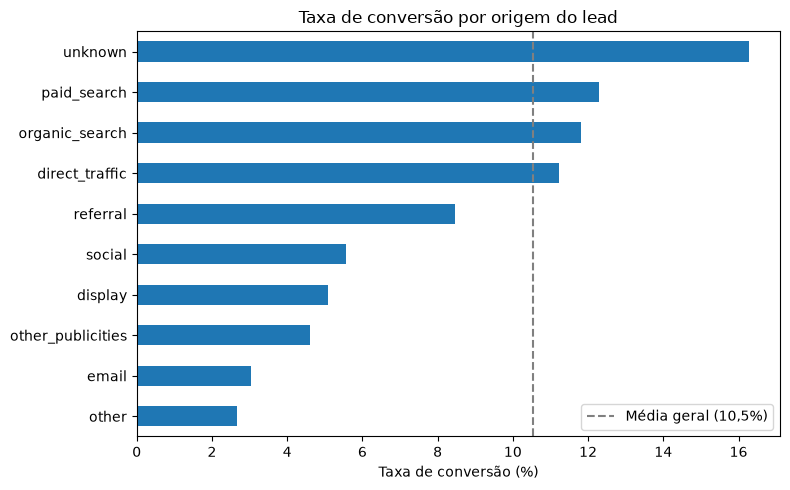

In [18]:
import matplotlib.pyplot as plt

taxa = funil.groupby("origin")["convertido"].mean().sort_values() * 100
media = funil["convertido"].mean() * 100

ax = taxa.plot(kind="barh", figsize=(8, 5), label="_nolegend_")
ax.axvline(media, linestyle="--", color="gray", label=f"Média geral ({media:.1f}%)".replace(".", ","))
ax.set_title("Taxa de conversão por origem do lead")
ax.set_xlabel("Taxa de conversão (%)")
ax.set_ylabel("")
ax.legend()

plt.tight_layout()
plt.savefig("conversao_por_origem.png", dpi=150)
plt.show()